In [ ]:
#Naïve Bayes example
import numpy as np
import pandas as pd

In [ ]:
def probabilidad_priori(y):
  classes, counts = np.unique(y, return_counts = True)
  priori = counts / len(y)
  return classes, priori

In [ ]:
def probabilidad_condicional(X, y, classes):
  prob_condicionales = [] #List to storage the probabilities values

  for c in classes:
    X_c = X[y == c]
    prob_c= []
    for feature in X_c.T:
      feature_values, counts = np.unique(feature, return_counts = True)
      prob = (counts + 1) / len(feature) + len(feature_values)
      prob_c.append((feature_values, prob))
    prob_condicionales.append(prob_c)
  return prob_condicionales

In [ ]:
def predict(X, clases, priori, prob_condicionales):
  predicciones = []
  for x in X:
    probs = []
    for i,c in enumerate(classes):
      class_prob = np.log(priori[i])
      for j, feature_value in enumerate(x):
        feature_values, prob = prob_condicionales[i][j]

        if feature_value in feature_values:
          class_prob += np.log(prob[np.where(feature_values == feature_value)])
        else:
          class_prob += np.log(1/len(feature_values) + 1)
      probs.append(class_prob)
    predicciones.append(classes[np.argmax(probs)])
  return predicciones

In [ ]:
#Previously executed in defined batches
y = [2, 2, 2, 1, 1, 0, 0, 0, 1, -1]
probabilidad_priori(y)

X = np.array([[2,2,3,1],[6,6,6,5]])
y = np.array([1,1,0,-1])
classes = np.array([1,0,-1])

#print(probabilidad_condicional(X,y,classes))   doesn't work :'v

In [ ]:
#Example
X_train = np.array([[0,1,3],[1,1,2],[0,1,0],[1,0,1],[0,0,0]])
y_train = np.array([1,1,1,0,0])
X_test = np.array([[0,1],[1,0]])

classes, priori = probabilidad_priori(y_train)
probabilidad_condicional = probabilidad_condicional(X_train, y_train, classes)

predicciones = predict(X_test, classes, priori, probabilidad_condicional)
print("Predicciones: ", predicciones)

Predicciones:  [1, 1]


Implementacion con scikit-learn https://dcain.etsin.upm.es/~carlos/bookAA/02.1_MetodosdeClasificacion-Naive-Bayes.html

In [ ]:
#sklearn

from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target']=iris['target']
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
from sklearn.model_selection import train_test_split
X, y = df.values[:,0:4], df.values[:,4]
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

In [ ]:
#y_test

array([0., 0., 0., 0., 1., 1., 1., 0., 1., 2., 2., 2., 1., 2., 1., 0., 0.,
       2., 0., 1., 2., 1., 1., 0., 2., 0., 0., 1., 2., 1., 0., 1., 2., 2.,
       0., 1., 2., 2.])

In [ ]:
# Vector de Medias
#numClases = np.size(np.unique(df['target']))
#mean_vectors = []
#for cl in range(numClases):
#    mean_vectors.append(np.mean(X_train[y_train==cl], axis=0))
#    print('Vector Media clase %s: %s\n' %(cl, mean_vectors[cl]))

Vector Media clase 0: [5.00540541 3.42432432 1.44324324 0.24864865]

Vector Media clase 1: [5.8972973  2.72702703 4.23513514 1.32432432]

Vector Media clase 2: [6.67368421 2.96842105 5.58421053 2.03421053]



In [ ]:
from sklearn.naive_bayes import GaussianNB
clf_NB = GaussianNB()
clf_NB.fit(X_train, y_train)
tot_Test = np.size(y_test)
tot_aciertos = 0
y_pred = []
for x, y in zip(X_test, y_test):
    y_est = clf_NB.predict([x])
    y_pred.append(y_est)
    if (y==y_est): tot_aciertos +=1
    #print('Instancia %s Clase real %s - Clase estimada %s \n' %(x, y, y_est))
print('Exactitud del clasificador (porcentaje de aciertos) = %s \n' %(tot_aciertos*100/tot_Test))

Exactitud del clasificador (porcentaje de aciertos) = 97.36842105263158 



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[13  0  0]
 [ 0 13  0]
 [ 0  1 11]]


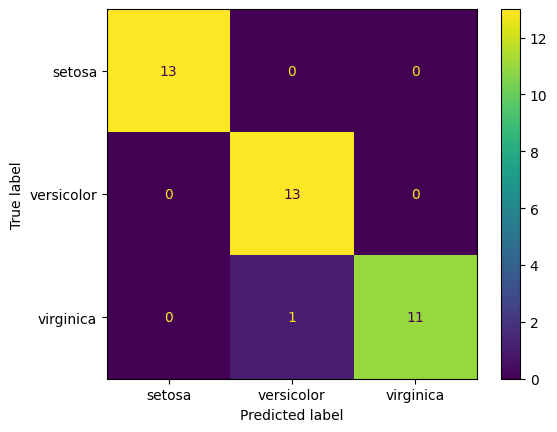

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
cm_display = ConfusionMatrixDisplay(cm, display_labels=iris['target_names']).plot()